# Loading Dataset

In [1]:
import pandas as pd

df = pd.read_csv("https://raw.githubusercontent.com/Muhanad-husn/Sleep-Health-and-Lifestyle/refs/heads/main/data.csv")
df

,Person ID,Gender,Age,Occupation,Sleep Duration,Quality of Sleep,Physical Activity Level,Stress Level,BMI Category,Blood Pressure,Heart Rate,Daily Steps,Sleep Disorder
0,1,Male,27,Software Engineer,6.1,6,42,6,Overweight,126/83,77,4200,NaN
1,2,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
2,3,Male,28,Doctor,6.2,6,60,8,Normal,125/80,75,10000,NaN
3,4,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
4,5,Male,28,Sales Representative,5.9,4,30,8,Obese,140/90,85,3000,Sleep Apnea
...,...,...,...,...,...,...,...,...,...,...,...,...,...
369,370,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
370,371,Female,59,Nurse,8.0,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
371,372,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea
372,373,Female,59,Nurse,8.1,9,75,3,Overweight,140/95,68,7000,Sleep Apnea


#
-----

# Binomial Distribution 
# Q.1) What is the probability that a randomly selected male has insomnia? 

In [3]:
male = df[df['Gender'] == 'Male']
p = (male['Sleep Disorder'] == 'Insomnia').mean()
print(p)

0.21693121693121692


#
-------

# Q.2) In a sample of 10 individuals diagnosed with insomnia, what is the probability that exactly 2 are male? 

In [6]:
# To find 'P'
male_insomnia = ((df['Gender'] == 'Male') & (df['Sleep Disorder'] == 'Insomnia')).sum()
total_insomnia = (df['Sleep Disorder'] == 'Insomnia').sum()
p = male_insomnia / total_insomnia
print(p)

0.5324675324675324


In [5]:
from scipy.stats import binom
n = 10   
k = 2    
p = 0.53 
prob = binom.pmf(k, n, p)

print(prob)

0.030098656904798994


#
------

# Q.3) In a sample of 10 individuals diagnosed with insomnia, what is the probability that at most 2 are male?

In [7]:
n = 10   
k = 2    
p = 0.53 
prob = binom.cdf(2, n, p)

print(prob)

0.03655603973460194


#
-----

# Q.4) In a sample of 10 individuals diagnosed with insomnia, what is the probability that at least 2 are male? 

In [8]:
n = 10   
k = 2    
p = 0.53 
prob = 1 - binom.cdf(2, n, p)

print(prob)

0.963443960265398


#
------

# Q.5) In a sample of 10 individuals diagnosed with insomnia, what is the most likely number of males? 

In [20]:
n = 10       
p = 0.53
most_likely =  binom.mean(n, p)
print(f"{most_likely:.0f}")

5


#
------

# Q.6) In a sample of 10 individuals diagnosed with insomnia, what is the median number of males, given that the probability of being male is 0.5?

In [22]:
n = 10       
p = 0.5
being_male =  binom.median(n, p)
print(f"{being_male:.2f}")

5.00


#
-----

# Q.7) In a sample of 100 individuals diagnosed with insomnia, what is the expected num ber of males?

In [23]:
n = 100       
p = 0.5
being_male =  binom.mean(n, p)
print(f"{being_male:.2f}")

50.00


#
-----

# Multinomial Distribution 
# Q.8) What are the probabilities of individuals experiencing and not experiencing various sleep disorders (Insomnia, Sleep Apnea, None)? 

In [32]:
p_insomnia = (df['Sleep Disorder'] == 'Insomnia').mean()
p_apnea = (df['Sleep Disorder'] == 'Sleep Apnea').mean()
p_none = (df['Sleep Disorder'] == 'None').mean()

print(p_insomnia, p_apnea, p_none)

0.20588235294117646 0.20855614973262032 0.0


# Q.9) In a sample of 20 individuals, what is the probability that 10 are unaffected, 5 have insomnia, and 5 have sleep apnea? 

In [37]:
from scipy.stats import multinomial
n = 20
x = [10, 5, 5]
p = [0.20588235294117646, 0.20855614973262032, 0.00]

prob = multinomial.pmf(x, n, p)
print(f"Probability: {prob:.5f}")

Probability: 0.00017


#
-----

# Poisson Distribution 
# Q.10) What is the mean duration (in minutes) of physical activity per day? 


In [42]:
mean_ =df[["Physical Activity Level"]].mean()
mean_

Physical Activity Level    59.171123
dtype: float64

#
-----

# Q.11) What is the probability that a randomly selected individual engages in at most 30 minutes of physical activity per day? 

In [44]:
from scipy.stats import poisson
prob_30 = poisson.cdf(30, mu = mean_)
print("Probability <= 30 minutes:", prob_30)

Probability <= 30 minutes: [2.1661821e-05]


# 
-----

# Q.12) What is the probability that a randomly selected individual engages in at least 60 minutes of physical activity per day? 

In [45]:
prob_60 = 1 - poisson.cdf(59, mu = mean_)
print("Probability ≥60 minutes:", prob_60)

Probability ≥60 minutes: [0.47432412]


#
------

# Q.13) What is the probability that a randomly selected individual engages in 50 to 60 minutes of physical activity per day? 

In [46]:
prob_50_60 = poisson.cdf(60, mu = mean_) - poisson.cdf(49, mu = mean_)
print("Probability between 50 and 60 minutes:", prob_50_60)

Probability between 50 and 60 minutes: [0.4750731]


# 
-------

# Q.14) What is the average duration of physical activity among individuals? Comment on the mean value. 

In [47]:
avg_activity = df["Physical Activity Level"].mean()
print("Average physical activity:", avg_activity)

Average physical activity: 59.17112299465241


#
-------

# Q.15) What is the shape of the distribution of physical activity durations, and what inferences can be drawn from it? 

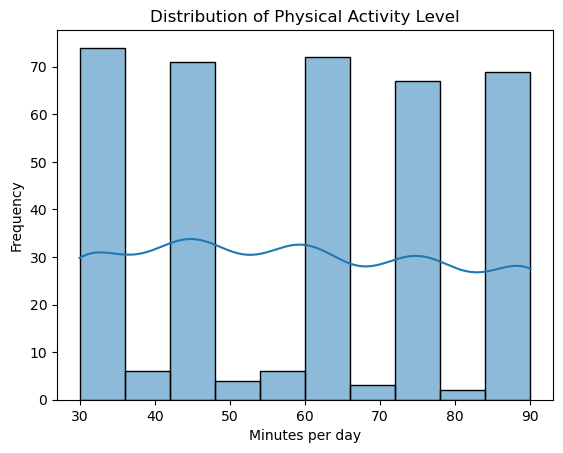

In [51]:
import seaborn as sns
import matplotlib.pyplot as plt
sns.histplot(df["Physical Activity Level"], kde=True)
plt.title("Distribution of Physical Activity Level")
plt.xlabel("Minutes per day")
plt.ylabel("Frequency")
plt.show()

#
----